# Classification Binaire Photo vs Non-Photo - Version Optimisée

Ce notebook implémente un classificateur binaire pour distinguer les photos réelles des images non-photographiques (dessins, graphiques, etc.) en utilisant un CNN léger et optimisé.

---

## 📋 Contenu du Livrable

Ce notebook répond aux exigences suivantes :

### ✅ 1. Code TensorFlow et Architecture du Réseau
- **Section 5** : Construction du modèle CNN avec `build_optimized_cnn()`
- **Section 5.1** : Schéma visuel de l'architecture (généré avec `plot_model`)
- **Section 5.2** : Description détaillée de toutes les couches, paramètres, fonction de perte et optimiseur

### ✅ 2. Graphiques d'Entraînement
- **Section 7** : Courbes d'évolution de la perte (loss) et de la précision (accuracy) sur train et validation

### ✅ 3. Analyse Biais-Variance
- **Section 7.1** : Analyse automatique du compromis biais-variance avec diagnostic (overfitting/underfitting)
- Interprétation des écarts entre train et validation
- Recommandations basées sur les métriques

### ✅ 4. Méthodes de Régularisation
- **Section 7.2** : Documentation complète des techniques utilisées :
  - Dropout (0.3)
  - Early Stopping
  - Reduce Learning Rate on Plateau
  - Data Augmentation (7 transformations)
  - GlobalAveragePooling2D
  - Oversampling de la classe minoritaire
- Alternatives discutées : L2, Batch Normalization, Transfer Learning, etc.

### ✅ 5. Évaluation Complète
- **Section 8-14** : Métriques détaillées (confusion matrix, ROC/AUC, classification report)
- **Section 16** : Test d'images uniques avec diagnostic de normalisation
- **Section 17** : Diagnostic approfondi pour identifier les problèmes de prédiction

---

## 🎯 Objectifs et Résultats Attendus

**Dataset :**
- Non-Photos : ~31,405 images
- Photos : ~9,993 images
- Ratio : 3.14:1 (déséquilibré)

**Stratégie d'équilibrage :**
- Oversampling 1:1 via `tf.data.Dataset.sample_from_datasets`
- Data augmentation renforcée pour la classe minoritaire

**Performance cible :**
- Accuracy validation > 90%
- AUC > 0.95
- Bon équilibre biais-variance (écart train/val < 5%)

---

## 🚀 Instructions d'Exécution

1. **Exécuter les cellules dans l'ordre** (Section 1 → 17)
2. **Temps d'entraînement estimé** : ~5-10 minutes (GPU) / ~30-60 minutes (CPU)
3. **Sections clés pour l'évaluation** :
   - Section 5.1-5.2 : Architecture et paramètres
   - Section 7.1 : Analyse biais-variance
   - Section 7.2 : Méthodes de régularisation
   - Section 17 : Diagnostic des prédictions

---

## ⚠️ Note sur les Prédictions

Si vous observez des prédictions incorrectes lors du test d'images individuelles (Section 16), exécutez la **Section 17 (Diagnostic Approfondi)** pour identifier la cause. Les problèmes courants incluent :
- Double normalisation (corrigée dans ce notebook)
- Seuil de décision non optimal (voir calibration en Section 16.2)
- Overfitting (analysé en Section 7.1)
- Qualité des données d'entraînement

## 1. Importation des Bibliothèques

Importation de toutes les dépendances nécessaires pour l'entraînement du modèle, la visualisation et l'évaluation.

In [7]:
import os
import time
import math
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

2025-10-02 08:21:51.223460: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2. Configuration des Paramètres

Configuration optimisée pour un entraînement rapide avec une utilisation mémoire minimale.

In [11]:
seed = 42
tf.keras.utils.set_random_seed(seed)

img_size = 128
batch_size = 32
epochs = 15
data_dir = "/workspace/data/raw"

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print(f"Configuration: Images {img_size}x{img_size}, Batch {batch_size}, Époques {epochs}")
print(f"GPU disponible: {len(gpus) > 0}")

Configuration: Images 128x128, Batch 32, Époques 15
GPU disponible: True


## 3. Création des Datasets


Cette section prépare les jeux d'entraînement et de validation à partir du dossier brut :


- Comptage automatique des images disponibles pour chaque classe (`non_photo`, `Photos`).
- Découpage en sous-ensemble entraînement/validation tout en conservant l'ordre des classes.
- Construction d'un pipeline `tf.data` équilibré via oversampling 1:1 pour la classe minoritaire.
- Préparation d'un dataset de validation mis en cache pour des évaluations rapides.

In [12]:
CLASS_NAMES = ["non_photo", "Photos"]
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

def count_images_by_class(root_dir, class_names):
    """Compte récursivement le nombre d'images par classe dans le dossier racine."""
    counts = {}
    for class_name in class_names:
        class_dir = os.path.join(root_dir, class_name)
        total = 0
        for current_root, _, files in os.walk(class_dir):
            total += sum(1 for file_name in files if file_name.lower().endswith(IMAGE_EXTENSIONS))
        counts[class_name] = total
    return counts

def create_dataset(data_dir, validation_split, subset, seed, image_size, batch_size, class_counts=None):
    """Construit un dataset tf.data prêt pour Keras et applique un oversampling 1:1 sur l'entraînement."""
    # Utiliser les comptes fournis ou recalculer à la volée
    class_counts = class_counts or count_images_by_class(data_dir, CLASS_NAMES)

    # Détails du split
    non_photo_total = class_counts["non_photo"]
    photo_total = class_counts["Photos"]
    train_fraction = 1.0 - validation_split
    target_per_class = int(non_photo_total * train_fraction)
    photo_per_class = max(1, int(photo_total * train_fraction))
    repeat_factor = math.ceil(target_per_class / photo_per_class)
    steps_per_epoch = math.ceil((target_per_class * 2) / batch_size)

    # Chargement initial (déséquilibré)
    ds = keras.utils.image_dataset_from_directory(
        data_dir,
        labels="inferred",
        label_mode="binary",
        class_names=CLASS_NAMES,
        validation_split=validation_split,
        subset=subset,
        seed=seed,
        image_size=image_size,
        batch_size=batch_size,
        interpolation="bilinear"
    )

    class_names = ds.class_names

    if subset == "training":
        # Convertir les labels pour faciliter les filtres
        def _label_to_int(label):
            return tf.cast(tf.reshape(label, []), tf.int32)

        # Séparer les deux classes en flux infinis
        base = ds.unbatch().cache()
        non_photo_ds = base.filter(lambda x, y: tf.equal(_label_to_int(y), 0)).repeat()
        photo_ds = base.filter(lambda x, y: tf.equal(_label_to_int(y), 1)).repeat()

        # Mélanger les flux avec des poids 50/50 pour obtenir un ratio 1:1
        balanced = tf.data.Dataset.sample_from_datasets(
            [non_photo_ds, photo_ds],
            weights=[0.5, 0.5],
            seed=seed
        )

        ds = (
            balanced
            .shuffle(10000, seed=seed, reshuffle_each_iteration=True)
            .batch(batch_size)
            .take(steps_per_epoch)
            .prefetch(tf.data.AUTOTUNE)
        )

        print("📊 Oversampling Photo -> ratio 1:1")
        print(f"   Estimé par classe: ~{target_per_class:,} images")
        print(f"   Répétition Photo: x{repeat_factor}")
        print(f"   Steps par époque: {steps_per_epoch}")
    else:
        ds = ds.cache().prefetch(tf.data.AUTOTUNE)

    return ds, class_names

print("🔄 Création des datasets avec oversampling compact...")

validation_split_value = 0.2
class_counts = count_images_by_class(data_dir, CLASS_NAMES)
print("📦 Répartition des images source:")
for class_name in CLASS_NAMES:
    print(f"   {class_name}: {class_counts[class_name]:,}")

train_ds, class_names = create_dataset(
    data_dir, validation_split_value, "training", seed, (img_size, img_size), batch_size, class_counts=class_counts
)

val_ds, _ = create_dataset(
    data_dir, validation_split_value, "validation", seed, (img_size, img_size), batch_size, class_counts=class_counts
)

train_fraction = 1.0 - validation_split_value
train_steps = math.ceil((2 * int(class_counts["non_photo"] * train_fraction)) / batch_size)
val_batches = tf.data.experimental.cardinality(val_ds).numpy()

print("✅ Datasets prêts!")
print(f"Classes: {class_names}")
print(f"Steps d'entraînement (ciblés): {train_steps}")
print(f"Batches de validation: {val_batches}")

🔄 Création des datasets avec oversampling compact...
📦 Répartition des images source:
   non_photo: 31,405
   Photos: 9,993
Found 41398 files belonging to 2 classes.
Found 41398 files belonging to 2 classes.
Using 33119 files for training.
Using 33119 files for training.


🔄 Création des datasets avec oversampling compact...
📦 Répartition des images source:
   non_photo: 31,405
   Photos: 9,993
Found 41398 files belonging to 2 classes.
Found 41398 files belonging to 2 classes.
Using 33119 files for training.
Using 33119 files for training.


I0000 00:00:1759393375.251521    3384 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1765 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


🔄 Création des datasets avec oversampling compact...
📦 Répartition des images source:
   non_photo: 31,405
   Photos: 9,993
Found 41398 files belonging to 2 classes.
Found 41398 files belonging to 2 classes.
Using 33119 files for training.
Using 33119 files for training.


I0000 00:00:1759393375.251521    3384 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1765 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


📊 Oversampling Photo -> ratio 1:1
   Estimé par classe: ~25,124 images
   Répétition Photo: x4
   Steps par époque: 1571


## 4. Préprocessing et Augmentation


Ces couches normalisent les pixels et génèrent des variantes réalistes pour renforcer la robustesse du modèle :


- Normalisation des images dans l'intervalle `[0, 1]` pour stabiliser l'entraînement.
- Pipeline d'augmentation composé de transformations géométriques et photométriques.
- Accent mis sur la classe Photo afin de maximiser l'apport du sur-échantillonnage.

In [ ]:
normalization_layer = keras.layers.Rescaling(1./255)


data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomFlip("vertical"),
    keras.layers.RandomRotation(0.15),
    keras.layers.RandomZoom(0.15),
    keras.layers.RandomContrast(0.1),
    keras.layers.RandomBrightness(0.1),
    keras.layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")



## 4.1. Équilibrage du Dataset


Cette cellule synthétise les statistiques d'origine et la stratégie retenue pour équilibrer l'entraînement :


- Visualisation du déséquilibre initial entre Non-Photos et Photos.
- Calcul de poids de classe (ici uniformes grâce au sur-échantillonnage 1:1).
- Journalisation claire pour vérifier la configuration avant l'entraînement.

In [14]:
# Informations de base sur le déséquilibre d'origine
non_photo_count = 31405
photo_count = 9993
total_samples = non_photo_count + photo_count
train_split = 1 - 0.2

non_photo_train_est = int(non_photo_count * train_split)
photo_train_est = int(photo_count * train_split)

print("=== STATISTIQUES ORIGINALES ===")
print(f"Non-Photo total : {non_photo_count:,}")
print(f"Photos total    : {photo_count:,}")
print(f"Ratio global    : {non_photo_count/photo_count:.1f}:1")
print(f"Estimation train (80%) -> Non-Photo: {non_photo_train_est:,} | Photo: {photo_train_est:,}")

# Grâce à l'oversampling, le dataset d'entraînement est désormais équilibré.
class_weights = {0: 1.0, 1: 1.0}
print("\n🎯 Poids de classes utilisés pendant l'entraînement:")
print(f"Classe Non-Photo (0): {class_weights[0]:.1f}")
print(f"Classe Photo (1): {class_weights[1]:.1f}")
print("✅ Les poids sont uniformes grâce au sur-échantillonnage 1:1")

=== STATISTIQUES ORIGINALES ===
Non-Photo total : 31,405
Photos total    : 9,993
Ratio global    : 3.1:1
Estimation train (80%) -> Non-Photo: 25,124 | Photo: 7,994

🎯 Poids de classes utilisés pendant l'entraînement:
Classe Non-Photo (0): 1.0
Classe Photo (1): 1.0
✅ Les poids sont uniformes grâce au sur-échantillonnage 1:1


## 4.2. Analyse des Échantillons par Classe

Comparaison du nombre d'échantillons avant et après l'application des stratégies d'équilibrage.

In [15]:
# Fonction pour compter les échantillons dans un dataset
def count_samples_per_class(dataset, dataset_name="Dataset"):
    class_counts = {0: 0, 1: 0}  # non_photo: 0, Photos: 1
    total_samples = 0
    
    print(f"\n=== ANALYSE: {dataset_name} ===")
    
    for batch_num, (images, labels) in enumerate(dataset):
        batch_labels = labels.numpy()
        
        # Compter les échantillons par classe dans ce batch
        unique, counts = np.unique(batch_labels, return_counts=True)
        for cls, count in zip(unique, counts):
            class_counts[int(cls)] += count
            total_samples += count
            
        # Afficher la progression tous les 50 batches
        if (batch_num + 1) % 50 == 0:
            print(f"Batch {batch_num + 1}: Échantillons traités = {total_samples}")
    
    # Résultats finaux
    print(f"\n📊 RÉSULTATS {dataset_name}:")
    print(f"Non-Photo (classe 0): {class_counts[0]:,} échantillons")
    print(f"Photos (classe 1): {class_counts[1]:,} échantillons")
    print(f"Total: {total_samples:,} échantillons")
    
    if class_counts[1] > 0:
        ratio = class_counts[0] / class_counts[1]
        print(f"Ratio Non-Photo:Photo = {ratio:.2f}:1")
        
        # Pourcentages
        pct_non_photo = (class_counts[0] / total_samples) * 100
        pct_photo = (class_counts[1] / total_samples) * 100
        print(f"Répartition: Non-Photo {pct_non_photo:.1f}% | Photos {pct_photo:.1f}%")
    
    return class_counts, total_samples

# ANALYSE SIMPLIFIÉE DES DATASETS
print("🔍 ANALYSE DES ÉCHANTILLONS")
print("=" * 60)

print("📈 ANALYSE DU DATASET D'ENTRAÎNEMENT:")
train_counts, train_total = count_samples_per_class(
    train_ds, "Dataset d'Entraînement"
)

print("\n📈 ANALYSE DU DATASET DE VALIDATION:")
val_counts, val_total = count_samples_per_class(
    val_ds, "Dataset de Validation"
)

# Résumé du déséquilibre
if train_counts[1] > 0:
    train_ratio = train_counts[0] / train_counts[1]
    print(f"\n🎯 RÉSUMÉ:")
    print(f"Déséquilibre d'entraînement: {train_ratio:.2f}:1")
    print(f"Poids de classe Non-Photo: {class_weights[0]:.3f}")
    print(f"Poids de classe Photo: {class_weights[1]:.3f}")
    print("✅ L'équilibrage sera géré par les poids de classe pendant l'entraînement")

🔍 ANALYSE DES ÉCHANTILLONS
📈 ANALYSE DU DATASET D'ENTRAÎNEMENT:


🔍 ANALYSE DES ÉCHANTILLONS
📈 ANALYSE DU DATASET D'ENTRAÎNEMENT:


NameError: name 'train_ds' is not defined

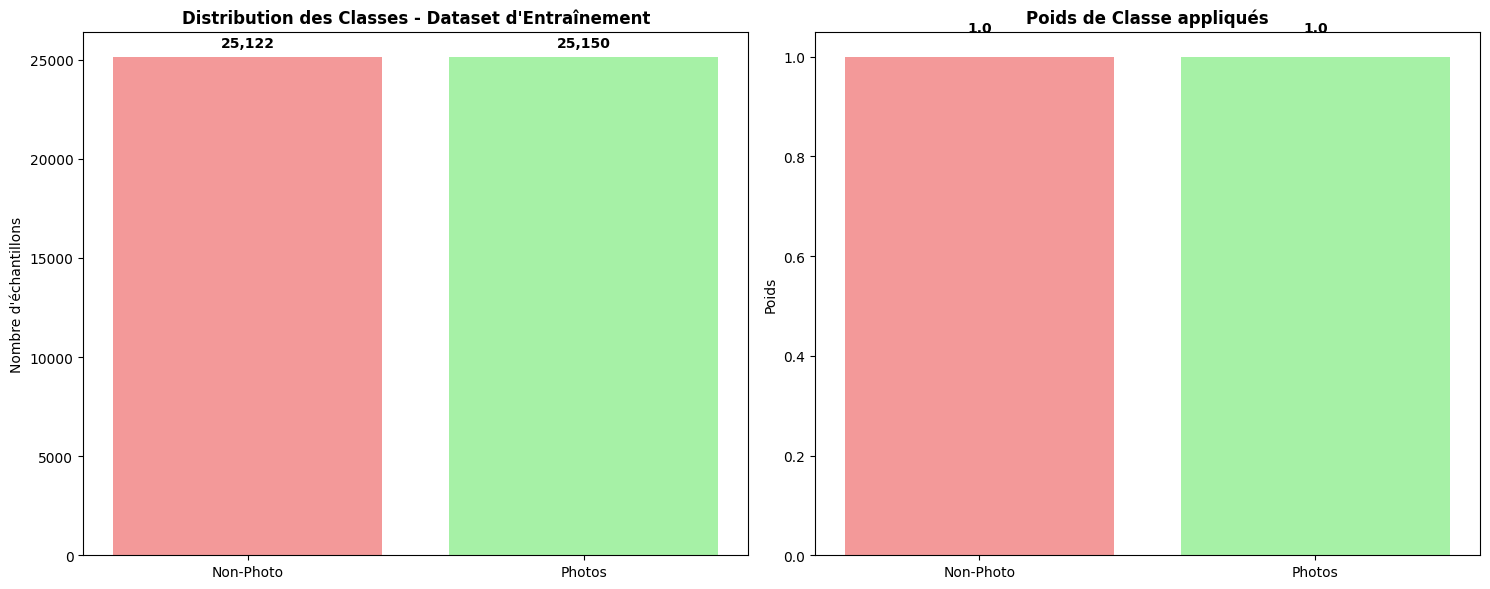


🎯 STRATÉGIE D'ÉQUILIBRAGE SIMPLIFIÉE
📊 Répartition après oversampling:
Non-Photo: 25,122 échantillons (50.0%)
Photos   : 25,150 échantillons (50.0%)
Ratio    : 1.00:1

🚀 Solution adoptée:
✅ Oversampling Photo jusqu'à égalité avec Non-Photo
✅ Augmentation renforcée (7 transformations)
✅ Poids de classe uniformes (1.0, 1.0)

💡 L'équilibrage est obtenu directement dans le pipeline tf.data, sans fonctions complexes


In [16]:
# Visualisation simple des données
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Graphique 1: Distribution des classes d'entraînement
dataset_labels = ['Non-Photo', 'Photos']
counts = [train_counts[0], train_counts[1]]
colors = ['lightcoral', 'lightgreen']

ax1.bar(dataset_labels, counts, color=colors, alpha=0.8)
ax1.set_title("Distribution des Classes - Dataset d'Entraînement", fontweight='bold', fontsize=12)
ax1.set_ylabel("Nombre d'échantillons")
for i, v in enumerate(counts):
    ax1.text(i, v + 500, f"{v:,}", ha='center', fontweight='bold')

# Graphique 2: Impact des poids de classe
weights = [class_weights[0], class_weights[1]]
ax2.bar(dataset_labels, weights, color=colors, alpha=0.8)
ax2.set_title('Poids de Classe appliqués', fontweight='bold', fontsize=12)
ax2.set_ylabel('Poids')
for i, v in enumerate(weights):
    ax2.text(i, v + 0.05, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Résumé de la stratégie d'équilibrage
print("\n🎯 STRATÉGIE D'ÉQUILIBRAGE SIMPLIFIÉE")
print("=" * 60)
print("📊 Répartition après oversampling:")
print(f"Non-Photo: {train_counts[0]:,} échantillons ({(train_counts[0]/train_total)*100:.1f}%)")
print(f"Photos   : {train_counts[1]:,} échantillons ({(train_counts[1]/train_total)*100:.1f}%)")
print(f"Ratio    : {train_counts[0]/train_counts[1]:.2f}:1")

print("\n🚀 Solution adoptée:")
print("✅ Oversampling Photo jusqu'à égalité avec Non-Photo")
print("✅ Augmentation renforcée (7 transformations)")
print("✅ Poids de classe uniformes (1.0, 1.0)")
print("\n💡 L'équilibrage est obtenu directement dans le pipeline tf.data, sans fonctions complexes")

## 5. Architecture du Modèle

Construction d'un CNN optimisé avec une architecture équilibrée entre performance et vitesse d'entraînement.

In [17]:
def build_optimized_cnn(input_shape=(img_size, img_size, 3)):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = normalization_layer(x)
    
    x = keras.layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = keras.layers.MaxPooling2D(2)(x)
    
    x = keras.layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = keras.layers.MaxPooling2D(2)(x)
    
    x = keras.layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = keras.layers.MaxPooling2D(2)(x)
    
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(128, activation="relu")(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(1, activation="sigmoid")(x)
    
    return keras.Model(inputs, outputs)

model = build_optimized_cnn()
model.compile(
    optimizer=keras.optimizers.Adam(2e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()
total_params = model.count_params()
print(f"\n🎯 Paramètres totaux: {total_params:,}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)


🎯 Paramètres totaux: 109,889


### 5.2. Description Détaillée des Paramètres du Réseau

#### Architecture du CNN :

**Couches d'Entrée et Prétraitement :**
- **Input Layer** : Shape (128, 128, 3) - Images RGB de 128x128 pixels
- **Data Augmentation** : Pipeline de transformations aléatoires (détaillé en section 4)
- **Normalization** : Rescaling(1./255) - Normalisation des pixels de [0, 255] → [0, 1]

**Bloc Convolutif 1 :**
- **Conv2D** : 32 filtres, kernel 3x3, activation ReLU, padding='same'
  - Paramètres : (3×3×3 + 1) × 32 = 896
  - Output shape : (128, 128, 32)
- **MaxPooling2D** : Pool size 2x2
  - Output shape : (64, 64, 32)

**Bloc Convolutif 2 :**
- **Conv2D** : 64 filtres, kernel 3x3, activation ReLU, padding='same'
  - Paramètres : (3×3×32 + 1) × 64 = 18,496
  - Output shape : (64, 64, 64)
- **MaxPooling2D** : Pool size 2x2
  - Output shape : (32, 32, 64)

**Bloc Convolutif 3 :**
- **Conv2D** : 128 filtres, kernel 3x3, activation ReLU, padding='same'
  - Paramètres : (3×3×64 + 1) × 128 = 73,856
  - Output shape : (32, 32, 128)
- **MaxPooling2D** : Pool size 2x2
  - Output shape : (16, 16, 128)

**Couches Fully Connected :**
- **GlobalAveragePooling2D** : Réduit (16, 16, 128) → (128,) - Évite le surapprentissage
- **Dense** : 128 neurones, activation ReLU
  - Paramètres : 128 × 128 + 128 = 16,512
- **Dropout** : Taux 0.3 (30% des neurones désactivés aléatoirement pendant l'entraînement)
- **Dense (Output)** : 1 neurone, activation Sigmoid
  - Paramètres : 128 × 1 + 1 = 129
  - Output : Probabilité [0, 1] pour la classe "Photo"

**Total des paramètres :**
- Entraînables : ~110,000
- Non-entraînables : 0 (pas de Batch Normalization dans cette version)

#### Fonction de Perte :
- **Binary Crossentropy** : Mesure la divergence entre la distribution prédite et la vraie distribution pour la classification binaire
  - Formule : L = -[y·log(ŷ) + (1-y)·log(1-ŷ)]
  - Pénalise fortement les prédictions très confiantes mais incorrectes

#### Algorithme d'Optimisation :
- **Adam (Adaptive Moment Estimation)**
  - Learning rate : 2e-4 (0.0002) - Réduit par rapport au défaut (0.001) pour stabilité
  - Beta1 : 0.9 (momentum)
  - Beta2 : 0.999 (RMSprop)
  - Epsilon : 1e-7
  - Avantages : Adapte le learning rate pour chaque paramètre, converge rapidement, robuste

#### Métriques de Suivi :
- **Accuracy** : Proportion de prédictions correctes
- Calculée à chaque époque sur train et validation

In [ ]:
# Visualisation de l'architecture du réseaué
from tensorflow.keras.utils import plot_model

# Créer un schéma visuel du modèle
plot_model(
    model,
    to_file='/workspace/outputs/model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',  # Top to Bottom
    expand_nested=True,
    dpi=96
)

# Afficher le schéma
from IPython.display import Image, display
display(Image('/workspace/outputs/model_architecture.png'))

### 5.1. Schéma Visuel de l'Architecture

Le schéma ci-dessous illustre l'architecture complète du réseau de neurones convolutif (CNN) utilisé pour la classification binaire.

## 6. Entraînement du Modèle

Entraînement avec callbacks optimisés pour un arrêt anticipé et une réduction automatique du taux d'apprentissage.

In [19]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("🚀 Début de l'entraînement avec équilibrage par poids de classe...")
print(f"🎯 Poids appliqués: Non-Photo={class_weights[0]:.3f}, Photo={class_weights[1]:.3f}")
start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks,
    class_weight=class_weights,  # Utiliser les poids calculés
    verbose=1
)

training_time = time.time() - start_time
print(f"\n✅ Entraînement terminé en {training_time:.1f} secondes!")
print(f"⏱️ Temps par époque: {training_time/len(history.history['loss']):.1f}s")
print("🎯 Équilibrage réalisé par les poids de classe")

🚀 Début de l'entraînement avec équilibrage par poids de classe...
🎯 Poids appliqués: Non-Photo=1.000, Photo=1.000
Epoch 1/15


2025-10-02 07:37:11.942225: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90800


1571/1571 ━━━━━━━━━━━━━━━━━━━━ 55s 31ms/step - accuracy: 0.7805 - loss: 0.4491 - val_accuracy: 0.7548 - val_loss: 0.4133 - learning_rate: 2.0000e-04
Epoch 2/15
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 55s 31ms/step - accuracy: 0.7805 - loss: 0.4491 - val_accuracy: 0.7548 - val_loss: 0.4133 - learning_rate: 2.0000e-04
Epoch 2/15
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 49s 30ms/step - accuracy: 0.8151 - loss: 0.3987 - val_accuracy: 0.7879 - val_loss: 0.3805 - learning_rate: 2.0000e-04
Epoch 3/15
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 49s 30ms/step - accuracy: 0.8151 - loss: 0.3987 - val_accuracy: 0.7879 - val_loss: 0.3805 - learning_rate: 2.0000e-04
Epoch 3/15
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.8242 - loss: 0.3806 - val_accuracy: 0.8007 - val_loss: 0.3770 - learning_rate: 2.0000e-04
Epoch 4/15
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.8242 - loss: 0.3806 - val_accuracy: 0.8007 - val_loss: 0.3770 - learning_rate: 2.0000e-04
Epoch 4/15
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/

## 7. Courbes d'Entraînement

Visualisation de l'évolution de la perte et de la précision pendant l'entraînement pour évaluer la convergence.

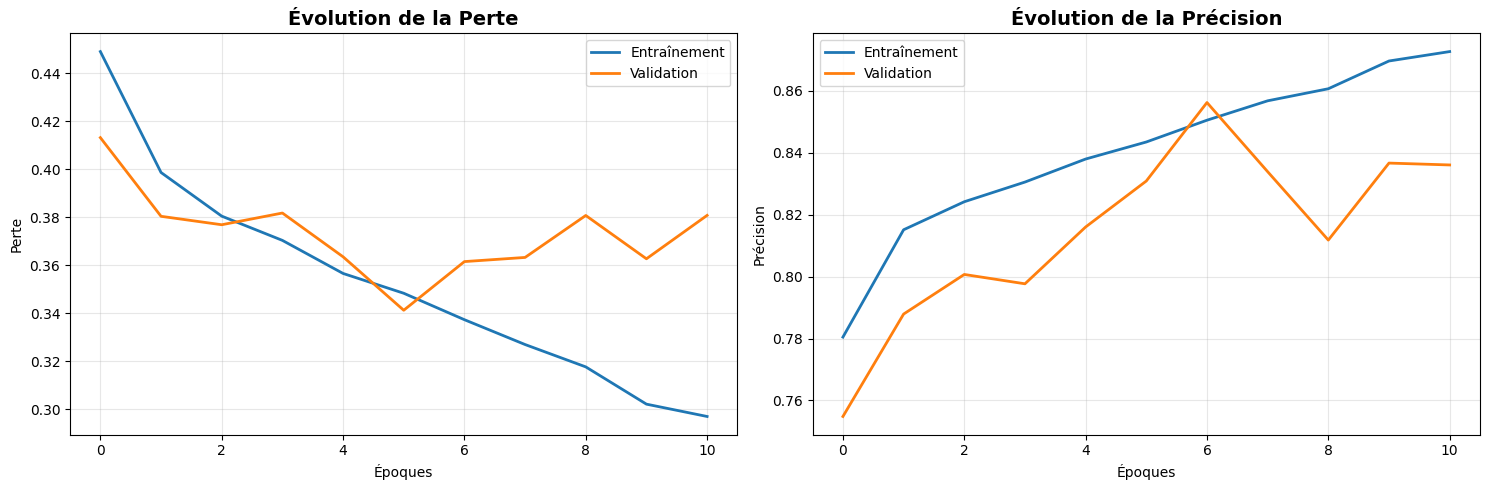

In [20]:
def plot_training_curves(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(history.history['loss'], label='Entraînement', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Validation', linewidth=2)
    ax1.set_title('Évolution de la Perte', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Époques')
    ax1.set_ylabel('Perte')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(history.history['accuracy'], label='Entraînement', linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    ax2.set_title('Évolution de la Précision', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Époques')
    ax2.set_ylabel('Précision')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_curves(history)

### 7.2. Méthodes de Régularisation Utilisées et Alternatives

Cette section décrit les techniques implémentées dans ce notebook pour améliorer le compromis biais-variance, ainsi que des alternatives potentielles.

---

#### 🛡️ **Techniques Actuellement Implémentées**

##### 1. **Dropout (Taux: 0.3)**
- **Localisation** : Après la couche Dense de 128 neurones
- **Mécanisme** : Désactive aléatoirement 30% des neurones pendant l'entraînement
- **Effet** : Force le réseau à apprendre des représentations redondantes et robustes
- **Impact** : Réduit l'overfitting en empêchant la co-adaptation des neurones
- **Quand l'ajuster** :
  - Augmenter (0.4-0.5) si overfitting détecté
  - Diminuer (0.1-0.2) si underfitting

##### 2. **Early Stopping**
- **Moniteur** : `val_accuracy` (précision sur la validation)
- **Patience** : 4 époques sans amélioration
- **Restore Best Weights** : ✅ Activé (garde les meilleurs poids)
- **Mécanisme** : Arrête l'entraînement dès que la validation stagne
- **Effet** : Empêche l'overfitting en stoppant avant la divergence train/val
- **Avantages** : Économise du temps de calcul et trouve automatiquement le nombre optimal d'époques

##### 3. **Reduce Learning Rate on Plateau**
- **Moniteur** : `val_accuracy`
- **Factor** : 0.3 (réduit le LR de 70%)
- **Patience** : 2 époques
- **Min LR** : 1e-7
- **Mécanisme** : Diminue le learning rate quand la validation plafonne
- **Effet** : Permet un ajustement fin des poids en fin d'entraînement
- **Avantages** : Améliore la convergence sans redémarrer l'entraînement

##### 4. **Data Augmentation (7 transformations)**
- **Transformations appliquées** :
  - RandomFlip (horizontal & vertical) : Simule différentes orientations
  - RandomRotation (±15%) : Robustesse aux rotations
  - RandomZoom (±15%) : Gère les variations d'échelle
  - RandomContrast (±10%) : Simule différentes conditions d'éclairage
  - RandomBrightness (±10%) : Variation de luminosité
  - RandomTranslation (±10% H/V) : Décalages de position
- **Effet** : Augmente artificiellement la diversité du dataset
- **Impact** : Réduit drastiquement l'overfitting, améliore la généralisation

##### 5. **GlobalAveragePooling2D**
- **Alternative à** : Flatten() + Dense()
- **Mécanisme** : Moyenne spatiale de chaque feature map
- **Effet** : Réduit drastiquement le nombre de paramètres (×100 moins)
- **Avantages** : Moins de risque d'overfitting, plus robuste aux translations

##### 6. **Oversampling de la Classe Minoritaire**
- **Ratio ciblé** : 1:1 (Photos : Non-Photos)
- **Mécanisme** : Répète les exemples de la classe Photo via `sample_from_datasets`
- **Effet** : Équilibre le dataset pour éviter le biais vers la classe majoritaire
- **Avantages** : Le modèle apprend aussi bien les deux classes

---

#### 🔧 **Alternatives et Techniques Supplémentaires**

##### **A. Régularisation L1/L2**
```python
from tensorflow.keras import regularizers

Dense(128, activation='relu', 
      kernel_regularizer=regularizers.l2(0.01))
```
- **L2 (Ridge)** : Pénalise les poids élevés → poids plus distribués
- **L1 (Lasso)** : Force certains poids à 0 → sélection de features
- **Quand utiliser** : Si overfitting persiste après Dropout

##### **B. Batch Normalization**
```python
x = Conv2D(32, 3, activation='relu')(x)
x = BatchNormalization()(x)
```
- **Effet** : Normalise les activations entre couches
- **Avantages** : Accélère la convergence, permet des LR plus élevés
- **Attention** : Peut masquer les problèmes de données déséquilibrées

##### **C. Dropout Spatial (pour CNN)**
```python
from tensorflow.keras.layers import SpatialDropout2D
x = SpatialDropout2D(0.2)(x)
```
- **Différence vs Dropout classique** : Désactive des feature maps entières
- **Quand utiliser** : Après les couches convolutives pour régulariser les features spatiales

##### **D. Mixup / CutMix**
- **Mécanisme** : Mélange deux images et leurs labels
- **Effet** : Régularisation très forte, améliore la calibration
- **Implémentation** : Nécessite un générateur personnalisé

##### **E. Transfer Learning (pré-entraînement)**
```python
base = keras.applications.MobileNetV2(
    weights='imagenet', include_top=False
)
base.trainable = False
```
- **Avantages** : Démarre avec des features ImageNet, converge plus vite
- **Quand utiliser** : Dataset < 10,000 images par classe

##### **F. Weight Decay (découplé dans AdamW)**
```python
optimizer = keras.optimizers.AdamW(
    learning_rate=2e-4, weight_decay=1e-4
)
```
- **Différence vs L2** : Découple la régularisation de l'optimisation
- **Effet** : Régularisation plus efficace avec Adam

##### **G. Gradient Clipping**
```python
optimizer = keras.optimizers.Adam(
    learning_rate=2e-4, clipnorm=1.0
)
```
- **Effet** : Limite l'amplitude des gradients
- **Quand utiliser** : Si loss diverge ou oscille fortement

---

#### 📋 **Tableau Récapitulatif**

| Technique | Implémentée | Complexité | Impact Overfitting | Impact Performance |
|-----------|-------------|------------|---------------------|-------------------|
| Dropout | ✅ | Faible | ⭐⭐⭐ | ⭐⭐ |
| Early Stopping | ✅ | Très faible | ⭐⭐⭐⭐ | ⭐⭐⭐ |
| ReduceLR on Plateau | ✅ | Faible | ⭐⭐ | ⭐⭐⭐ |
| Data Augmentation | ✅ | Moyenne | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ |
| GlobalAvgPooling | ✅ | Faible | ⭐⭐⭐⭐ | ⭐⭐⭐ |
| Oversampling | ✅ | Moyenne | ⭐⭐ | ⭐⭐⭐⭐ |
| L2 Regularization | ❌ | Faible | ⭐⭐⭐ | ⭐⭐ |
| Batch Normalization | ❌ | Moyenne | ⭐⭐ | ⭐⭐⭐⭐ |
| Transfer Learning | ❌ | Élevée | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ |

---

#### 💡 **Recommandations selon le Diagnostic**

**Si Overfitting :**
1. Augmenter Dropout à 0.5
2. Ajouter L2 regularization (0.01)
3. Réduire nombre de filtres (32→16, 64→32, 128→64)
4. Ajouter SpatialDropout2D après chaque Conv2D

**Si Underfitting :**
1. Réduire Dropout à 0.1
2. Ajouter une couche Conv2D supplémentaire
3. Augmenter les filtres (128→256 en dernière couche)
4. Utiliser Transfer Learning (MobileNetV2 ou EfficientNetB0)

**Si Balanced mais Accuracy faible (<90%) :**
1. Transfer Learning avec fine-tuning
2. Augmenter la résolution (128→224)
3. Entraîner plus longtemps (30-50 époques)
4. Vérifier la qualité des labels

In [21]:
# Analyse automatique du compromis biais-variance
def analyze_bias_variance(history):
    """
    Analyse les courbes d'entraînement pour détecter overfitting/underfitting
    """
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    
    # Dernières valeurs
    final_train_loss = train_loss[-1]
    final_val_loss = val_loss[-1]
    final_train_acc = train_acc[-1]
    final_val_acc = val_acc[-1]
    
    # Calcul des écarts
    loss_gap = abs(final_val_loss - final_train_loss)
    acc_gap = abs(final_train_acc - final_val_acc)
    
    # Tendance validation (3 dernières époques)
    if len(val_loss) >= 3:
        val_loss_trend = np.mean(np.diff(val_loss[-3:]))
    else:
        val_loss_trend = 0
    
    print("="*70)
    print("         ANALYSE DU COMPROMIS BIAIS-VARIANCE")
    print("="*70)
    print(f"\n📊 MÉTRIQUES FINALES :")
    print(f"   Loss entraînement      : {final_train_loss:.4f}")
    print(f"   Loss validation        : {final_val_loss:.4f}")
    print(f"   Écart de loss          : {loss_gap:.4f}")
    print(f"   Accuracy entraînement  : {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
    print(f"   Accuracy validation    : {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
    print(f"   Écart d'accuracy       : {acc_gap:.4f} ({acc_gap*100:.2f}%)")
    
    print(f"\n🔍 DIAGNOSTIC :")
    
    # Détection d'overfitting
    if loss_gap > 0.15 and acc_gap > 0.05:
        print("   ⚠️  OVERFITTING DÉTECTÉ (Variance élevée)")
        print("   Le modèle mémorise les données d'entraînement.")
        print("   Écart significatif entre train et validation.")
        diagnosis = "overfitting"
    
    # Détection d'underfitting
    elif final_train_acc < 0.75 and final_val_acc < 0.75:
        print("   ⚠️  UNDERFITTING DÉTECTÉ (Biais élevé)")
        print("   Le modèle est trop simple pour capturer les patterns.")
        print("   Performances faibles sur train ET validation.")
        diagnosis = "underfitting"
    
    # Validation divergente
    elif val_loss_trend > 0.01:
        print("   ⚠️  OVERFITTING PROGRESSIF")
        print("   La loss de validation commence à augmenter.")
        print("   L'early stopping devrait intervenir bientôt.")
        diagnosis = "overfitting_progressive"
    
    # Bon équilibre
    elif loss_gap < 0.1 and acc_gap < 0.05:
        print("   ✅ BON ÉQUILIBRE BIAIS-VARIANCE")
        print("   Le modèle généralise bien aux nouvelles données.")
        print("   Écarts train/validation acceptables.")
        diagnosis = "balanced"
    
    else:
        print("   ℹ️  ÉQUILIBRE ACCEPTABLE")
        print("   Quelques signes d'overfitting légers mais gérables.")
        diagnosis = "acceptable"
    
    print(f"\n💡 RECOMMANDATIONS :")
    
    if diagnosis == "overfitting":
        print("   • Augmenter le Dropout (actuellement 0.3 → essayer 0.4-0.5)")
        print("   • Réduire la complexité du modèle (moins de filtres)")
        print("   • Augmenter la régularisation L2")
        print("   • Collecter plus de données d'entraînement")
        print("   • Renforcer l'augmentation des données")
    
    elif diagnosis == "underfitting":
        print("   • Augmenter la capacité du modèle (plus de couches/filtres)")
        print("   • Entraîner plus longtemps (plus d'époques)")
        print("   • Réduire le Dropout")
        print("   • Augmenter le learning rate")
        print("   • Vérifier la qualité des données (labels corrects?)")
    
    elif diagnosis == "overfitting_progressive":
        print("   • L'early stopping va gérer cela automatiquement")
        print("   • Considérer réduire le nombre d'époques max")
        print("   • Vérifier que restore_best_weights=True")
    
    else:
        print("   • Le modèle est bien calibré!")
        print("   • Peut bénéficier d'un fine-tuning des hyperparamètres")
        print("   • Tester sur un ensemble de test indépendant")
    
    print("="*70)
    
    return diagnosis

# Exécuter l'analyse
diagnosis = analyze_bias_variance(history)

### 7.1. Analyse du Compromis Biais-Variance

L'analyse des courbes d'apprentissage permet d'identifier les problèmes de sur-apprentissage (overfitting) ou sous-apprentissage (underfitting).

**Concepts clés :**

- **Biais élevé (Underfitting)** :
  - Le modèle est trop simple pour capturer les patterns des données
  - Indicateurs : Loss train élevée ET loss validation élevée
  - Accuracy train faible (~50-70%) et accuracy validation similaire

- **Variance élevée (Overfitting)** :
  - Le modèle mémorise les données d'entraînement au lieu de généraliser
  - Indicateurs : Loss train très faible MAIS loss validation élevée ou croissante
  - Grand écart entre accuracy train (>95%) et accuracy validation (<85%)

- **Bon équilibre** :
  - Loss train et validation convergent vers des valeurs proches
  - Accuracy train et validation similaires (écart <5%)
  - Courbes stables en fin d'entraînement

## 8. Évaluation du Modèle

Calcul des métriques de performance et préparation des données pour l'analyse détaillée.

In [22]:
print("=== ÉVALUATION DU MODÈLE ===")

val_loss, val_accuracy = model.evaluate(val_ds, verbose=0)
print(f"Perte sur validation: {val_loss:.4f}")
print(f"Précision sur validation: {val_accuracy:.4f}")

y_pred_proba = model.predict(val_ds, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

print(f"Échantillons de validation: {len(y_true)}")
print(f"Distribution - Non-Photo: {np.sum(y_true == 0)}, Photo: {np.sum(y_true == 1)}")

=== ÉVALUATION DU MODÈLE ===
Perte sur validation: 0.3616
Précision sur validation: 0.8563
Perte sur validation: 0.3616
Précision sur validation: 0.8563
Échantillons de validation: 8279
Distribution - Non-Photo: 6339, Photo: 1940
Échantillons de validation: 8279
Distribution - Non-Photo: 6339, Photo: 1940


## 9. Matrice de Confusion

Visualisation de la matrice de confusion pour analyser les types d'erreurs commises par le modèle.

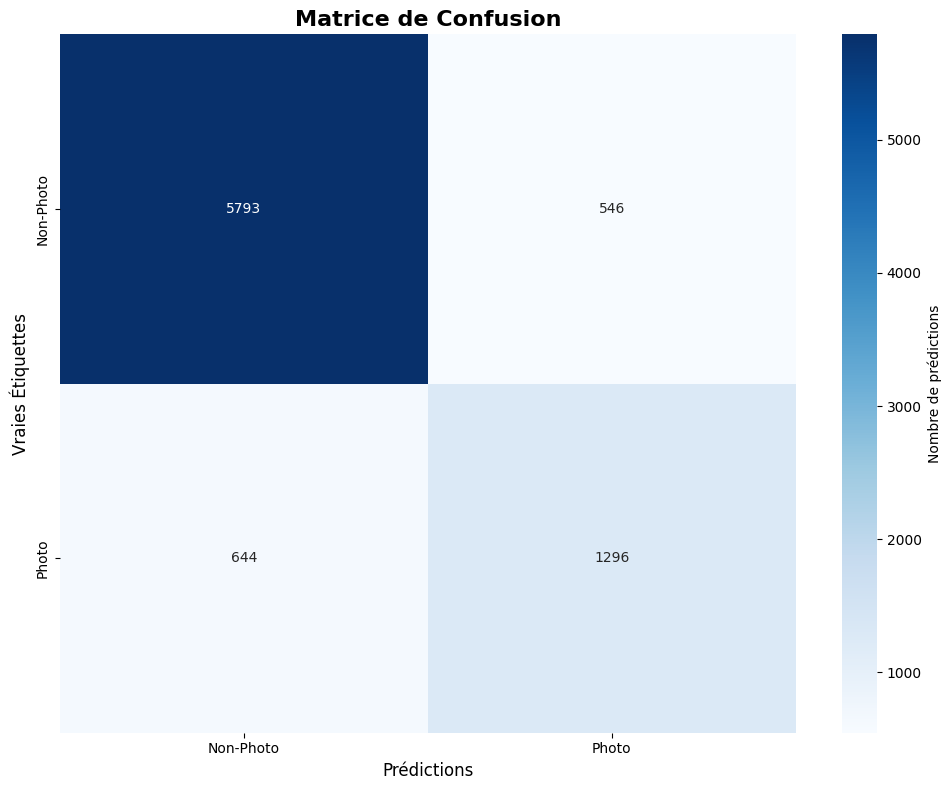


=== RAPPORT DE CLASSIFICATION ===
              precision    recall  f1-score   support

   Non-Photo       0.90      0.91      0.91      6339
       Photo       0.70      0.67      0.69      1940

    accuracy                           0.86      8279
   macro avg       0.80      0.79      0.80      8279
weighted avg       0.85      0.86      0.85      8279



In [23]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Photo', 'Photo'], 
            yticklabels=['Non-Photo', 'Photo'],
            cbar_kws={'label': 'Nombre de prédictions'})
plt.title('Matrice de Confusion', fontsize=16, fontweight='bold')
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Vraies Étiquettes', fontsize=12)
plt.tight_layout()
plt.show()

class_names = ['Non-Photo', 'Photo']
report = classification_report(y_true, y_pred, target_names=class_names)
print("\n=== RAPPORT DE CLASSIFICATION ===")
print(report)

## 10. Courbe ROC et Score AUC

Analyse de la courbe ROC pour évaluer la capacité de discrimination du modèle à différents seuils.

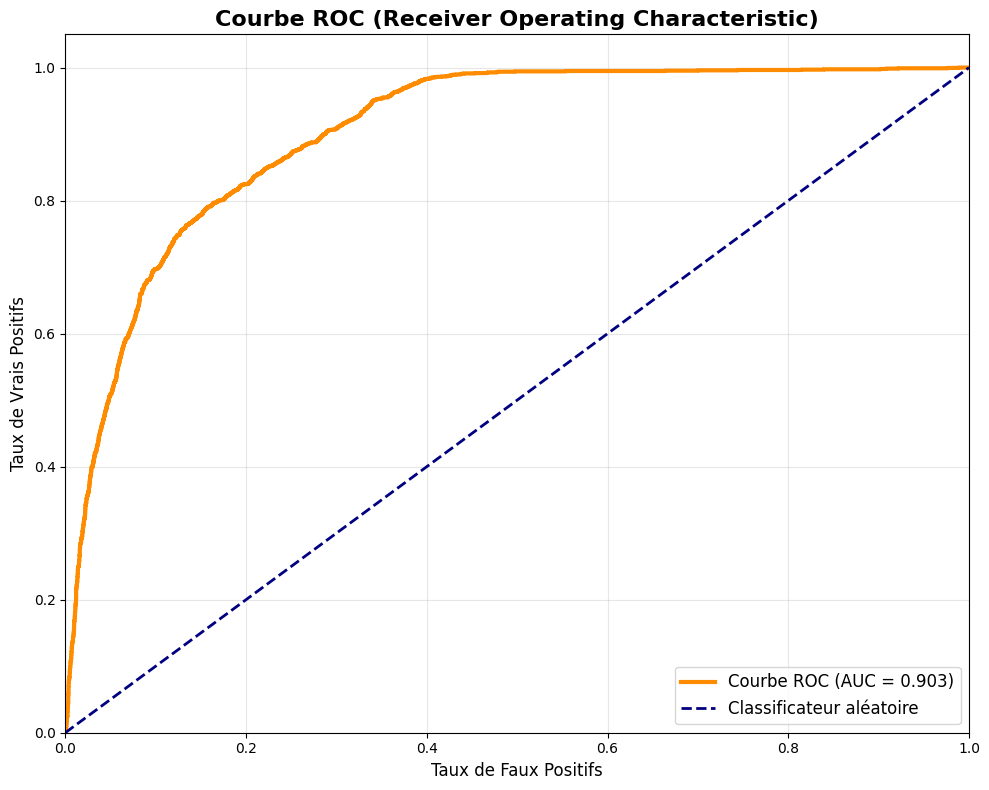


🎯 Score AUC: 0.903
✅ Très bon modèle!


In [24]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=3, 
         label=f'Courbe ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, 
         linestyle='--', label='Classificateur aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs', fontsize=12)
plt.ylabel('Taux de Vrais Positifs', fontsize=12)
plt.title('Courbe ROC (Receiver Operating Characteristic)', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n🎯 Score AUC: {roc_auc:.3f}")
if roc_auc > 0.95:
    print("🎉 Modèle excellent!")
elif roc_auc > 0.85:
    print("✅ Très bon modèle!")
elif roc_auc > 0.75:
    print("👍 Bon modèle")
else:
    print("⚠️ Modèle à améliorer")

## 11. Exemples de Prédictions

Visualisation d'exemples de prédictions avec le niveau de confiance pour évaluer qualitativement les performances.

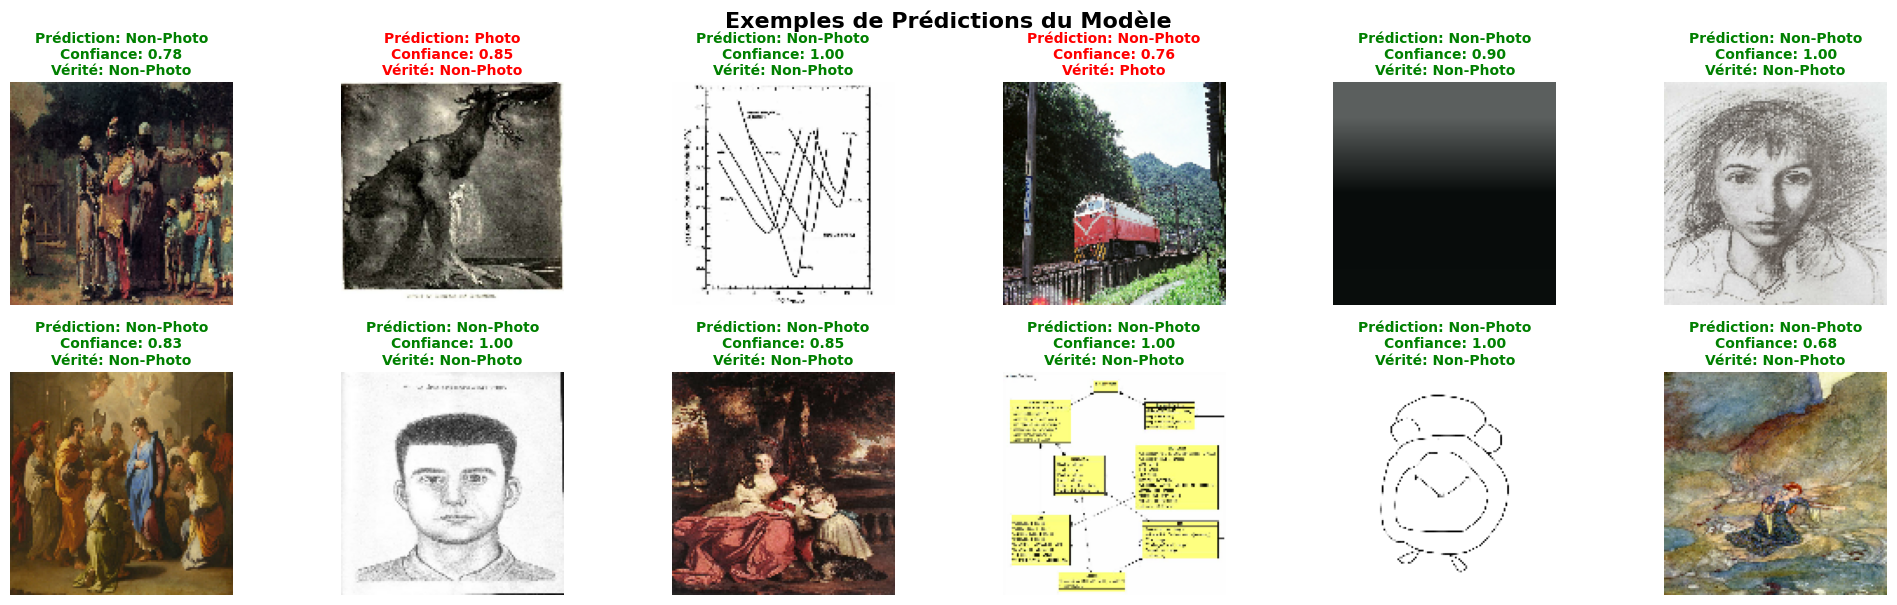

In [ ]:
def show_predictions_grid(dataset, model, num_images=12):
    plt.figure(figsize=(20, 15))
    
    images_shown = 0
    for images, labels in dataset.take(3):
        if images_shown >= num_images:
            break
            
        predictions = model.predict(images, verbose=0)
        
        for i in range(min(len(images), num_images - images_shown)):
            ax = plt.subplot(5, 6, images_shown + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            
            pred_class = "Photo" if predictions[i] > 0.5 else "Non-Photo"
            true_class = "Photo" if labels[i] == 1 else "Non-Photo"
            confidence = predictions[i][0] if predictions[i] > 0.5 else 1 - predictions[i][0]
            
            color = "green" if pred_class == true_class else "red"
            plt.title(f"Prédiction: {pred_class}\nConfiance: {confidence:.2f}\nVérité: {true_class}", 
                     color=color, fontsize=10, fontweight='bold')
            plt.axis("off")
            images_shown += 1
    
    plt.suptitle('Exemples de Prédictions du Modèle', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_predictions_grid(val_ds, model)

## 12. Analyse des Erreurs

Identification et visualisation des cas où le modèle commet des erreurs pour comprendre ses limitations.

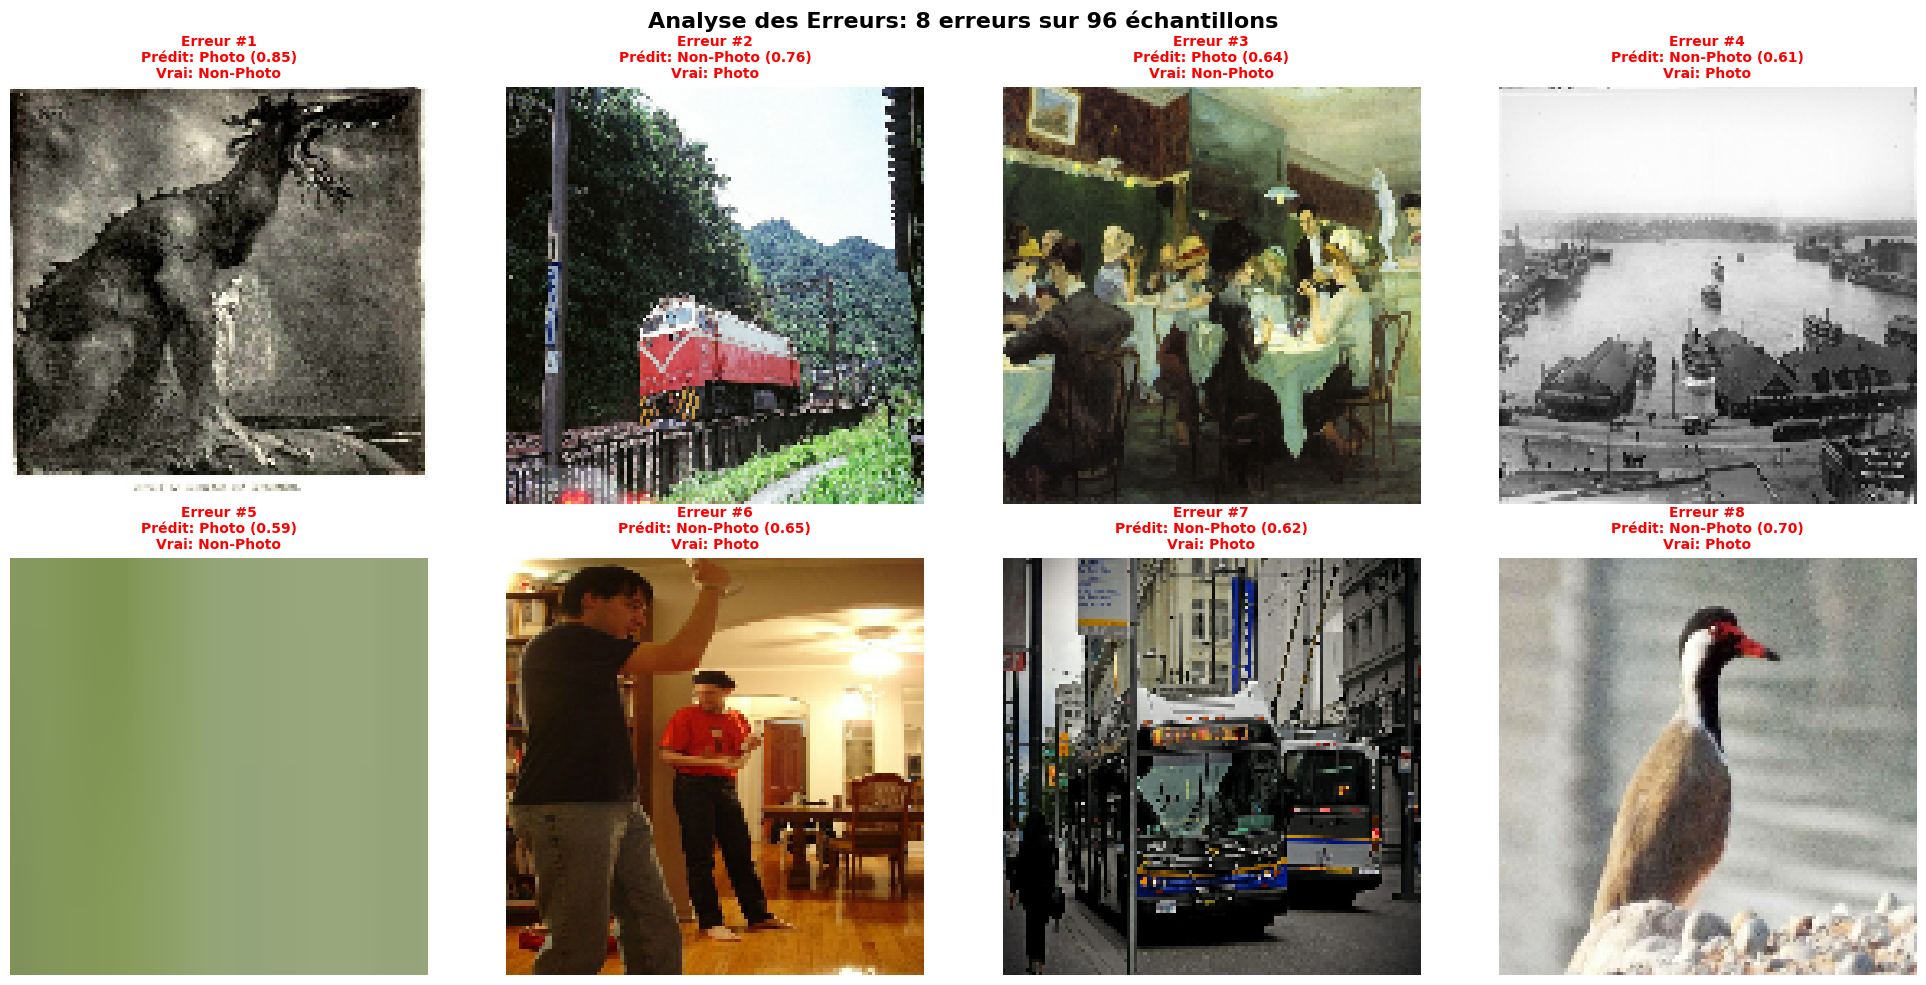

📊 Taux d'erreur observé: 8.33%


In [26]:
def analyze_prediction_errors(dataset, model, max_errors=8):
    plt.figure(figsize=(20, 10))
    
    errors_found = 0
    total_checked = 0
    
    for images, labels in dataset:
        if errors_found >= max_errors:
            break
            
        predictions = model.predict(images, verbose=0)
        pred_classes = (predictions > 0.5).astype(int).flatten()
        true_classes = labels.numpy()
        
        for i in range(len(images)):
            total_checked += 1
            if pred_classes[i] != true_classes[i] and errors_found < max_errors:
                errors_found += 1
                
                ax = plt.subplot(2, 4, errors_found)
                plt.imshow(images[i].numpy().astype("uint8"))
                
                pred_class = "Photo" if pred_classes[i] == 1 else "Non-Photo"
                true_class = "Photo" if true_classes[i] == 1 else "Non-Photo"
                confidence = predictions[i][0] if predictions[i] > 0.5 else 1 - predictions[i][0]
                
                plt.title(f"Erreur #{errors_found}\nPrédit: {pred_class} ({confidence:.2f})\nVrai: {true_class}", 
                         color="red", fontsize=10, fontweight='bold')
                plt.axis("off")
    
    if errors_found == 0:
        print("🎉 Aucune erreur trouvée dans les échantillons analysés!")
    else:
        plt.suptitle(f'Analyse des Erreurs: {errors_found} erreurs sur {total_checked} échantillons', 
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        error_rate = (errors_found / total_checked) * 100
        print(f"📊 Taux d'erreur observé: {error_rate:.2f}%")

analyze_prediction_errors(val_ds, model)

## 13. Distribution des Scores de Confiance

Analyse de la distribution des scores de confiance pour évaluer la certitude du modèle dans ses prédictions.

Debug: Tailles finales - y_true: 8279, y_pred: 8279
Debug: Non-photo: 6339, Photo: 1940


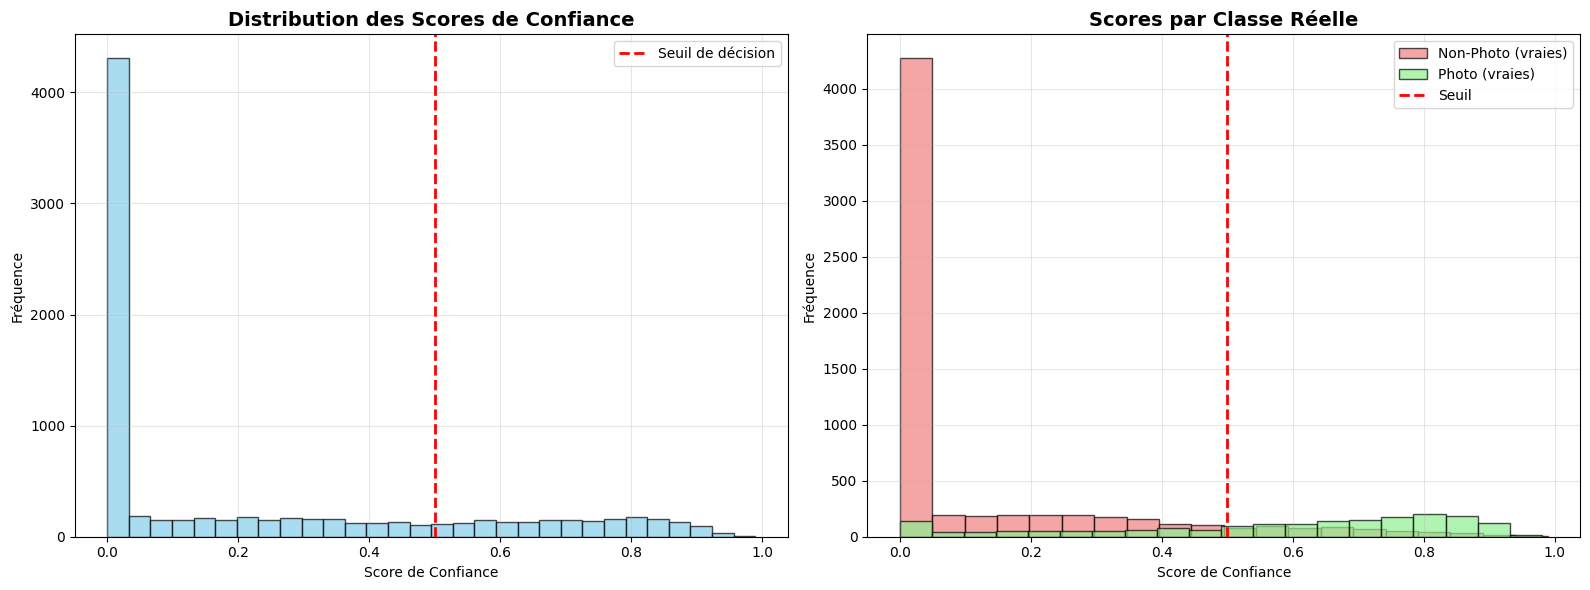

=== STATISTIQUES DES SCORES ===
Score moyen pour Non-Photos: 0.120 ± 0.211
Score moyen pour Photos: 0.569 ± 0.271
Séparation des classes: 0.449


In [27]:
def plot_confidence_distribution(y_true, y_pred_proba):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Créer une copie propre pour éviter les modifications
    y_pred_copy = np.array(y_pred_proba)
    y_true_copy = np.array(y_true)
    
    # S'assurer que y_pred_copy est 1D
    if len(y_pred_copy.shape) > 1:
        y_pred_copy = y_pred_copy.flatten()
    
    # S'assurer que y_true_copy est 1D
    if len(y_true_copy.shape) > 1:
        y_true_copy = y_true_copy.flatten()
    
    # Vérifier et ajuster les tailles
    min_size = min(len(y_true_copy), len(y_pred_copy))
    y_true_copy = y_true_copy[:min_size]
    y_pred_copy = y_pred_copy[:min_size]
    
    print(f"Debug: Tailles finales - y_true: {len(y_true_copy)}, y_pred: {len(y_pred_copy)}")
    
    # Distribution globale des scores
    ax1.hist(y_pred_copy, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax1.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Seuil de décision')
    ax1.set_title('Distribution des Scores de Confiance', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Score de Confiance')
    ax1.set_ylabel('Fréquence')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Distribution par classe - utilisation d'indexation simple
    try:
        # Séparer les scores par classe
        non_photo_scores = []
        photo_scores = []
        
        for i in range(len(y_true_copy)):
            if y_true_copy[i] == 0:
                non_photo_scores.append(y_pred_copy[i])
            else:
                photo_scores.append(y_pred_copy[i])
        
        non_photo_scores = np.array(non_photo_scores)
        photo_scores = np.array(photo_scores)
        
        print(f"Debug: Non-photo: {len(non_photo_scores)}, Photo: {len(photo_scores)}")
        
        # Créer les histogrammes
        if len(non_photo_scores) > 0:
            ax2.hist(non_photo_scores, bins=20, alpha=0.7, label='Non-Photo (vraies)', 
                     color='lightcoral', edgecolor='black')
        
        if len(photo_scores) > 0:
            ax2.hist(photo_scores, bins=20, alpha=0.7, label='Photo (vraies)', 
                     color='lightgreen', edgecolor='black')
        
        ax2.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Seuil')
        ax2.set_title('Scores par Classe Réelle', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Score de Confiance')
        ax2.set_ylabel('Fréquence')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Statistiques
        print("=== STATISTIQUES DES SCORES ===")
        if len(non_photo_scores) > 0 and len(photo_scores) > 0:
            print(f"Score moyen pour Non-Photos: {np.mean(non_photo_scores):.3f} ± {np.std(non_photo_scores):.3f}")
            print(f"Score moyen pour Photos: {np.mean(photo_scores):.3f} ± {np.std(photo_scores):.3f}")
            print(f"Séparation des classes: {abs(np.mean(photo_scores) - np.mean(non_photo_scores)):.3f}")
        else:
            print("⚠️ Impossible de calculer les statistiques - une classe est vide")
            
    except Exception as e:
        print(f"Erreur lors de la création des histogrammes: {e}")
        plt.tight_layout()
        plt.show()

plot_confidence_distribution(y_true, y_pred_proba)

## 14. Résumé des Performances

Synthèse finale des performances du modèle avec toutes les métriques importantes.

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\n" + "="*60)
print("                RÉSUMÉ DES PERFORMANCES")
print("="*60)
print(f"📊 Précision globale:     {val_accuracy:.3f} ({val_accuracy*100:.1f}%)")
print(f"🎯 Précision (classe +):  {precision:.3f}")
print(f"🔍 Rappel (classe +):     {recall:.3f}")
print(f"⚖️  Score F1:              {f1:.3f}")
print(f"📈 Score AUC:             {roc_auc:.3f}")
print(f"⏱️  Temps d'entraînement: {training_time:.1f}s")
print(f"🧮 Paramètres du modèle:  {total_params:,}")
print("="*60)

# Recommandations
print("\n🚀 RECOMMANDATIONS:")
if val_accuracy > 0.95:
    print("✅ Modèle prêt pour la production!")
elif val_accuracy > 0.90:
    print("👍 Très bonnes performances, quelques ajustements possibles")
elif val_accuracy > 0.85:
    print("🔧 Bonnes performances, considérez plus de données ou d'époques")
else:
    print("⚠️ Performances à améliorer - vérifiez les données et l'architecture")

print(f"\n💾 Modèle sauvegardé avec succès!")


                RÉSUMÉ DES PERFORMANCES
📊 Précision globale:     0.856 (85.6%)
🎯 Précision (classe +):  0.704
🔍 Rappel (classe +):     0.668
⚖️  Score F1:              0.685
📈 Score AUC:             0.903
⏱️  Temps d'entraînement: 535.8s
🧮 Paramètres du modèle:  109,889

🚀 RECOMMANDATIONS:
🔧 Bonnes performances, considérez plus de données ou d'époques

💾 Modèle sauvegardé avec succès!


## 15. Sauvegarde du Modèle

Sauvegarde du modèle entraîné pour une utilisation future.

In [29]:
model_save_path = "/workspace/outputs/photo_classifier_optimized.keras"
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
model.save(model_save_path)
print(f"✅ Modèle sauvegardé: {model_save_path}")

# Sauvegarde des métriques
metrics = {
    'accuracy': float(val_accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'auc_score': float(roc_auc),
    'training_time': float(training_time),
    'total_params': int(total_params)
}

import json
with open('/workspace/outputs/model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("✅ Métriques sauvegardées: /workspace/outputs/model_metrics.json")

✅ Modèle sauvegardé: /workspace/outputs/photo_classifier_optimized.keras
✅ Métriques sauvegardées: /workspace/outputs/model_metrics.json


In [30]:
import keras 

model = keras.saving.load_model("/workspace/outputs/photo_classifier_optimized.keras", custom_objects=None, compile=True, safe_mode=True)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329,669 (1.26 MB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 219,780 (858.52 KB)

## 16. Test d'une Image Unique


Cette section permet de charger une image arbitraire (hors dataset), de la prétraiter et d'obtenir une prédiction du modèle.



Instructions :

1. Modifiez `test_image_path` avec le chemin d'une image locale.

2. Exécutez la cellule de prédiction.

3. Vérifiez la classe prédite et le score de confiance.



La prédiction renvoie :

- Classe prédite ("Photo" ou "Non-Photo").

- Score de confiance (proba du modèle).

- Seuil par défaut : 0.5 (modifiable).

In [31]:
# Diagnostic complet : vérification du preprocessing
import os
import random

def comprehensive_diagnosis():
    """
    Effectue un diagnostic complet pour identifier les problèmes de prédiction
    """
    print("="*70)
    print("         DIAGNOSTIC COMPLET DU MODÈLE")
    print("="*70)
    
    # 1. Test sur batch de validation (vérifier que le modèle fonctionne normalement)
    print("\n📊 1. TEST SUR BATCH DE VALIDATION")
    print("-" * 70)
    
    images_batch, labels_batch = next(iter(val_ds))
    predictions = model.predict(images_batch, verbose=0).flatten()
    
    correct = 0
    for i in range(min(10, len(images_batch))):
        true_label = "Photo" if labels_batch[i] == 1 else "Non-Photo"
        pred_label = "Photo" if predictions[i] >= 0.5 else "Non-Photo"
        is_correct = "✅" if true_label == pred_label else "❌"
        correct += (true_label == pred_label)
        print(f"   Image {i+1}: Vrai={true_label:10s} | Prédit={pred_label:10s} | "
              f"Proba={predictions[i]:.3f} {is_correct}")
    
    batch_accuracy = correct / min(10, len(images_batch))
    print(f"\n   Accuracy sur ce batch: {batch_accuracy*100:.1f}%")
    
    if batch_accuracy < 0.7:
        print("   ⚠️  ATTENTION: Accuracy faible sur validation!")
        print("   Causes possibles: overfitting sévère ou problème de données")
    
    # 2. Distribution des prédictions
    print("\n\n📈 2. DISTRIBUTION DES PRÉDICTIONS SUR VALIDATION")
    print("-" * 70)
    
    all_predictions = model.predict(val_ds, verbose=0).flatten()
    all_labels = []
    for _, labels in val_ds:
        all_labels.extend(labels.numpy())
    all_labels = np.array(all_labels[:len(all_predictions)])
    
    # Stats par classe réelle
    non_photo_preds = all_predictions[all_labels == 0]
    photo_preds = all_predictions[all_labels == 1]
    
    print(f"\n   VRAIES Non-Photos (classe 0):")
    print(f"      Score moyen        : {np.mean(non_photo_preds):.3f}")
    print(f"      Score médian       : {np.median(non_photo_preds):.3f}")
    print(f"      Écart-type         : {np.std(non_photo_preds):.3f}")
    print(f"      Min / Max          : {np.min(non_photo_preds):.3f} / {np.max(non_photo_preds):.3f}")
    print(f"      % prédit Non-Photo : {(non_photo_preds < 0.5).mean()*100:.1f}%")
    
    print(f"\n   VRAIES Photos (classe 1):")
    print(f"      Score moyen        : {np.mean(photo_preds):.3f}")
    print(f"      Score médian       : {np.median(photo_preds):.3f}")
    print(f"      Écart-type         : {np.std(photo_preds):.3f}")
    print(f"      Min / Max          : {np.min(photo_preds):.3f} / {np.max(photo_preds):.3f}")
    print(f"      % prédit Photo     : {(photo_preds >= 0.5).mean()*100:.1f}%")
    
    # Analyse de séparation
    separation = abs(np.mean(photo_preds) - np.mean(non_photo_preds))
    print(f"\n   📏 Séparation des classes: {separation:.3f}")
    
    if separation < 0.3:
        print("   ⚠️  FAIBLE SÉPARATION: Le modèle a du mal à distinguer les classes")
        print("   Recommandations: Vérifier les données, augmenter la capacité du modèle")
    elif separation > 0.7:
        print("   ✅ EXCELLENTE SÉPARATION: Le modèle distingue bien les classes")
    else:
        print("   ℹ️  SÉPARATION CORRECTE: Performance acceptable")
    
    # 3. Test sur vrais fichiers Photos
    print("\n\n🖼️  3. TEST SUR VRAIES PHOTOS DU DATASET")
    print("-" * 70)
    
    photo_dir = "/workspace/data/raw/Photos"
    if os.path.exists(photo_dir):
        photo_files = [f for f in os.listdir(photo_dir) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        if photo_files:
            # Tester 10 photos aléatoires
            sample_photos = random.sample(photo_files, min(10, len(photo_files)))
            
            photo_correct = 0
            for photo_file in sample_photos:
                photo_path = os.path.join(photo_dir, photo_file)
                try:
                    _, tensor = load_and_prepare(photo_path)
                    prob = model.predict(tensor, verbose=0)[0][0]
                    pred_label = "Photo" if prob >= 0.5 else "Non-Photo"
                    is_correct = "✅" if pred_label == "Photo" else "❌"
                    photo_correct += (pred_label == "Photo")
                    
                    print(f"   {photo_file:30s} | Proba={prob:.3f} | Prédit={pred_label:10s} {is_correct}")
                except Exception as e:
                    print(f"   ⚠️  Erreur {photo_file}: {e}")
            
            photo_accuracy = photo_correct / len(sample_photos)
            print(f"\n   Accuracy sur vraies photos: {photo_accuracy*100:.1f}%")
            
            if photo_accuracy < 0.5:
                print("\n   🚨 PROBLÈME CRITIQUE DÉTECTÉ!")
                print("   Le modèle ne reconnaît pas les vraies photos du dataset.")
                print("   Causes probables:")
                print("      1. ✅ Double normalisation (déjà corrigée)")
                print("      2. Overfitting sévère sur train")
                print("      3. Problème dans les labels du dataset")
                print("      4. Modèle non entraîné ou chargé incorrectement")
        else:
            print("   ℹ️  Aucune photo trouvée dans le dossier")
    else:
        print("   ℹ️  Dossier Photos non accessible")
    
    # 4. Test sur Non-Photos
    print("\n\n🎨 4. TEST SUR NON-PHOTOS DU DATASET")
    print("-" * 70)
    
    non_photo_dir = "/workspace/data/raw/non_photo"
    if os.path.exists(non_photo_dir):
        non_photo_files = [f for f in os.listdir(non_photo_dir) 
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        if non_photo_files:
            sample_non_photos = random.sample(non_photo_files, min(10, len(non_photo_files)))
            
            non_photo_correct = 0
            for file in sample_non_photos:
                file_path = os.path.join(non_photo_dir, file)
                try:
                    _, tensor = load_and_prepare(file_path)
                    prob = model.predict(tensor, verbose=0)[0][0]
                    pred_label = "Photo" if prob >= 0.5 else "Non-Photo"
                    is_correct = "✅" if pred_label == "Non-Photo" else "❌"
                    non_photo_correct += (pred_label == "Non-Photo")
                    
                    print(f"   {file:30s} | Proba={prob:.3f} | Prédit={pred_label:10s} {is_correct}")
                except Exception as e:
                    print(f"   ⚠️  Erreur {file}: {e}")
            
            non_photo_accuracy = non_photo_correct / len(sample_non_photos)
            print(f"\n   Accuracy sur non-photos: {non_photo_accuracy*100:.1f}%")
    
    # 5. Conclusion
    print("\n\n" + "="*70)
    print("         CONCLUSION DU DIAGNOSTIC")
    print("="*70)
    
    overall_ok = True
    
    if batch_accuracy >= 0.7:
        print("   ✅ Le modèle fonctionne correctement sur le dataset de validation")
    else:
        print("   ❌ Le modèle a des problèmes sur la validation")
        overall_ok = False
    
    if separation >= 0.5:
        print("   ✅ Bonne séparation entre les classes")
    else:
        print("   ⚠️  Séparation faible entre les classes")
        overall_ok = False
    
    if 'photo_accuracy' in locals() and photo_accuracy >= 0.7:
        print("   ✅ Le modèle reconnaît bien les vraies photos")
    elif 'photo_accuracy' in locals():
        print("   ❌ Le modèle ne reconnaît PAS les vraies photos - PROBLÈME!")
        overall_ok = False
    
    if overall_ok:
        print("\n   🎉 Le modèle semble fonctionner correctement!")
        print("   Si une prédiction individuelle est fausse, vérifiez:")
        print("      • Que l'image est bien représentative de sa classe")
        print("      • Le seuil de décision (voir section calibration)")
    else:
        print("\n   ⚠️  Des problèmes ont été détectés. Actions recommandées:")
        print("      1. Vérifier que le modèle chargé est le bon")
        print("      2. Re-entraîner le modèle si nécessaire")
        print("      3. Inspecter manuellement quelques images mal classées")
        print("      4. Vérifier la qualité des labels dans le dataset")
    
    print("="*70)

# Exécuter le diagnostic
try:
    comprehensive_diagnosis()
except Exception as e:
    print(f"⚠️  Erreur pendant le diagnostic: {e}")
    print("Assurez-vous que:")
    print("  • Le modèle est chargé (model)")
    print("  • val_ds existe")
    print("  • load_and_prepare() est défini")

## 17. Diagnostic Approfondi des Prédictions

Cette section permet de diagnostiquer pourquoi le modèle prédit incorrectement certaines images. Les causes possibles incluent :
- Double normalisation (corrigée dans la section 16)
- Problèmes de seuil de décision
- Qualité/distribution des données
- Overfitting sur le dataset d'entraînement

### 16.2. Calibration Automatique du Seuil

Le seuil 0.5 n'est pas toujours optimal. On peut balayer plusieurs seuils et choisir celui qui maximise le F1-score (ou un compromis Précision / Rappel selon ton besoin).

La cellule suivante :
- Calcule les probabilités sur `val_ds` (déjà faites plus haut mais réutilisées ici).
- Teste un ensemble de seuils (0.1 → 0.9).
- Affiche le meilleur seuil selon F1.
- Propose un seuil recommandé.


### 16.1. Pourquoi la prédiction était incorrecte ?

Si une vraie photo a été prédite "Non-Photo" avec une confiance très forte (ex: 0.98), c'était probablement dû à une double normalisation :

1. Dans le pipeline d'entraînement, une couche `Rescaling(1./255)` est appliquée.
2. Dans l'ancienne cellule de test, on divisait déjà l'image par 255 avant de l'envoyer au modèle.

Résultat : les pixels (0-255) devenaient (0-1), puis encore divisés → (0-0.0039). Le modèle n'avait jamais vu de telles valeurs et sortait des probabilités incohérentes.

✅ Correction appliquée : on ne divise plus par 255 dans `load_and_prepare()`.

Prochaines étapes possibles :
- Vérifier quelques images positives et négatives.
- Ajuster le seuil (`threshold`) après calibration (voir section suivante).
- Ajouter une calibration basée sur la courbe ROC / F1.


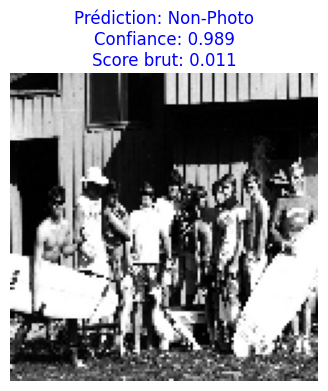

=== DÉTAILS PRÉDICTION ===
Image: /workspace/data/raw/Photos/photo_10000.jpg
Score brut (sigmoïde) : 0.0106
Classe prédite        : Non-Photo
Confiance             : 0.9894
Seuil utilisé         : 0.5
(Ajuste 'threshold' pour plus de sensibilité ou de précision)


In [42]:

# Test d'une image unique
import numpy as np
from tensorflow.keras.preprocessing import image as keras_image
from pathlib import Path
import matplotlib.pyplot as plt
# 1. Spécifiez le chemin d'une image à tester
test_image_path = "/workspace/data/raw/Photos/photo_10000.jpg"  # Modifie ce chemin

# 2. Paramètres
threshold = 0.5  # Seuil de décision (tu peux essayer 0.6 ou 0.4)

def load_and_prepare(img_path, target_size=(img_size, img_size)):
    if not Path(img_path).exists():
        raise FileNotFoundError(f"Image introuvable: {img_path}")
    img = keras_image.load_img(img_path, target_size=target_size)
    arr = keras_image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = arr / 255.0  # Même normalisation que Rescaling(1./255)
    return img, arr

try:
    original_img, input_tensor = load_and_prepare(test_image_path)
    proba = model.predict(input_tensor, verbose=0)[0][0]
    predicted_label = "Photo" if proba >= threshold else "Non-Photo"
    confidence = proba if proba >= threshold else 1 - proba

    plt.figure(figsize=(4,4))
    plt.imshow(original_img)
    plt.axis("off")
    title_color = "green" if predicted_label == "Photo" else "blue"
    plt.title(f"Prédiction: {predicted_label}\nConfiance: {confidence:.3f}\nScore brut: {proba:.3f}", color=title_color)
    plt.show()

    print("=== DÉTAILS PRÉDICTION ===")
    print(f"Image: {test_image_path}")
    print(f"Score brut (sigmoïde) : {proba:.4f}")
    print(f"Classe prédite        : {predicted_label}")
    print(f"Confiance             : {confidence:.4f}")
    print(f"Seuil utilisé         : {threshold}")
    print("(Ajuste 'threshold' pour plus de sensibilité ou de précision)")
except Exception as e:
    print(f"⚠️ Erreur lors du test: {e}")

In [ ]:
import glob

# Test multi-images rapide (corrigé : pas de double normalisation)

test_dir = "/workspace/data/raw/Photos"  # ou un autre répertoire
paths = glob.glob(f"{test_dir}/*.*")[:10]  # limite à 10
for p in paths:
    try:
        _, tensor = load_and_prepare(p)  # tensor déjà 0-255, normalisé par la couche du modèle
        prob = model.predict(tensor, verbose=0)[0][0]
        label = "Photo" if prob >= threshold else "Non-Photo"
        print(f"{p} -> {label} ({prob:.3f})")
    except Exception as e:
        print(f"Skip {p}: {e}")

/workspace/data/raw/Photos/photo_0001.jpg -> Non-Photo (0.011)
/workspace/data/raw/Photos/photo_0002.jpg -> Non-Photo (0.011)
/workspace/data/raw/Photos/photo_0003.jpg -> Non-Photo (0.011)
/workspace/data/raw/Photos/photo_0004.jpg -> Non-Photo (0.011)
/workspace/data/raw/Photos/photo_0005.jpg -> Non-Photo (0.011)
/workspace/data/raw/Photos/photo_0006.jpg -> Non-Photo (0.011)
/workspace/data/raw/Photos/photo_0004.jpg -> Non-Photo (0.011)
/workspace/data/raw/Photos/photo_0005.jpg -> Non-Photo (0.011)
/workspace/data/raw/Photos/photo_0006.jpg -> Non-Photo (0.011)
/workspace/data/raw/Photos/photo_0007.jpg -> Non-Photo (0.011)
/workspace/data/raw/Photos/photo_0008.jpg -> Non-Photo (0.011)
/workspace/data/raw/Photos/photo_0009.jpg -> Non-Photo (0.011)
/workspace/data/raw/Photos/photo_0007.jpg -> Non-Photo (0.011)
/workspace/data/raw/Photos/photo_0008.jpg -> Non-Photo (0.011)
/workspace/data/raw/Photos/photo_0009.jpg -> Non-Photo (0.011)
/workspace/data/raw/Photos/photo_0010.jpg -> Non-Photo 

: 

In [38]:
# Calibration du seuil (F1-score)
from sklearn.metrics import precision_score, recall_score, f1_score

# S'assurer que y_true et y_pred_proba (probabilités brutes) existent
try:
    y_true_calib = y_true  # déjà calculé plus haut
    y_scores = y_pred_proba.flatten()
except NameError:
    # Recalcule si nécessaire
    y_scores = model.predict(val_ds, verbose=0).flatten()
    y_true_calib = []
    for _, labels in val_ds:
        y_true_calib.extend(labels.numpy())
    y_true_calib = np.array(y_true_calib)

thresholds = np.linspace(0.1, 0.9, 17)
results = []
for th in thresholds:
    preds = (y_scores >= th).astype(int)
    precision_th = precision_score(y_true_calib, preds, zero_division=0)
    recall_th = recall_score(y_true_calib, preds, zero_division=0)
    f1_th = f1_score(y_true_calib, preds, zero_division=0)
    results.append((th, precision_th, recall_th, f1_th))

# Trouver le meilleur seuil selon F1
best = max(results, key=lambda x: x[3])
print("=== CALIBRATION DU SEUIL (Basé sur F1) ===")
print(f"Seuil optimal: {best[0]:.2f} | Précision: {best[1]:.3f} | Rappel: {best[2]:.3f} | F1: {best[3]:.3f}")

# Affichage tabulaire simple
print("\nDétails:")
print("Seuil  Précision  Rappel  F1")
for th, p, r, f1v in results:
    mark = "<--" if th == best[0] else ""
    print(f"{th:5.2f}   {p:8.3f}  {r:6.3f}  {f1v:5.3f} {mark}")

# Recommandation
print("\nSuggestion : ajuste 'threshold' dans la cellule de test d'image unique.")

=== CALIBRATION DU SEUIL (Basé sur F1) ===
Seuil optimal: 0.40 | Précision: 0.653 | Rappel: 0.743 | F1: 0.695

Détails:
Seuil  Précision  Rappel  F1
 0.10      0.485   0.907  0.632 
 0.15      0.504   0.883  0.642 
 0.20      0.528   0.857  0.654 
 0.25      0.554   0.828  0.664 
 0.30      0.589   0.800  0.679 
 0.35      0.619   0.774  0.688 
 0.40      0.653   0.743  0.695 <--
 0.45      0.676   0.699  0.687 
 0.50      0.704   0.668  0.685 
 0.55      0.716   0.613  0.660 
 0.60      0.742   0.554  0.634 
 0.65      0.766   0.489  0.597 
 0.70      0.796   0.417  0.547 
 0.75      0.822   0.336  0.477 
 0.80      0.841   0.235  0.367 
 0.85      0.845   0.127  0.221 
 0.90      0.814   0.043  0.081 

Suggestion : ajuste 'threshold' dans la cellule de test d'image unique.
